# emotion2vec Wagner-compatible VAD regression

Wagner et al. / audeering の wav2vec2 次元感情回帰に合わせ、emotion2vec 特徴から `arousal`, `dominance`, `valence` の 0..1 スコアを学習します。emotion2vec 本体は固定し、CSV+WAV から特徴抽出・キャッシュ・VADヘッド学習・評価を行います。


In [7]:
# このセルでは、VAD実験のCSVパス・特徴量キャッシュ・学習設定をまとめて定義する。

from pathlib import Path

# ---- dummy smoke-test config ----
CSV_PATH = Path('data/vad_labels_dummy.csv')
AUDIO_DIR = Path('.')
CACHE_DIR = Path('vad_downstream/cache/emotion2vec_vad_dummy')

MODEL_ID = 'iic/emotion2vec_base'
HUB = 'hf'  # use 'ms' or 'modelscope' if Hugging Face access is slow/unavailable

BATCH_SIZE = 2
EPOCHS = 1
LR = 1e-3
HIDDEN_DIM = 256
DROPOUT = 0.1

SPLIT_MODE = 'auto'  # auto, split, session, random
TEST_SESSION = None  # set a session id to run one held-out session; None runs all sessions in auto/session mode
SEED = 42
FORCE_EXTRACT = False


In [8]:
# このセルでは、プロジェクト内モジュールを読み込み、実験で使う乱数やデバイスを準備する。

import copy
import sys

import matplotlib.pyplot as plt
import numpy as np
import torch
from torch import optim
from tqdm.auto import tqdm

ROOT = Path.cwd()
if ROOT.name == 'vad_downstream':
    ROOT = ROOT.parent
VAD_DIR = ROOT / 'vad_downstream'
if str(VAD_DIR) not in sys.path:
    sys.path.insert(0, str(VAD_DIR))

from data import (
    WAGNER_VAD_COLUMNS,
    attach_cache_paths,
    build_vad_dataloader,
    ensure_feature_cache,
    leave_one_session_out_splits,
    load_vad_csv,
    split_vad_records,
)
from loss import vad_ccc_loss
from model import Emotion2VecVADRegressor, VAD_OUTPUT_NAMES, vad_tensor_to_dict

torch.manual_seed(SEED)
np.random.seed(SEED)
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

CSV_PATH = (ROOT / CSV_PATH).resolve() if not CSV_PATH.is_absolute() else CSV_PATH
AUDIO_DIR = (ROOT / AUDIO_DIR).resolve() if not AUDIO_DIR.is_absolute() else AUDIO_DIR
CACHE_DIR = (ROOT / CACHE_DIR).resolve() if not CACHE_DIR.is_absolute() else CACHE_DIR

print(f'ROOT      : {ROOT}')
print(f'CSV       : {CSV_PATH}')
print(f'AUDIO_DIR : {AUDIO_DIR}')
print(f'CACHE_DIR : {CACHE_DIR}')
print(f'DEVICE    : {DEVICE}')


ROOT      : c:\Users\RD004\Documents\lab\emotion2vec
CSV       : C:\Users\RD004\Documents\lab\emotion2vec\data\vad_labels_dummy.csv
AUDIO_DIR : C:\Users\RD004\Documents\lab\emotion2vec
CACHE_DIR : C:\Users\RD004\Documents\lab\emotion2vec\vad_downstream\cache\emotion2vec_vad_dummy
DEVICE    : cpu


CSV format:

```csv
file_path,valence,arousal,dominance,split
audio/sample001.wav,0.71,0.62,0.48,train
audio/sample002.wav,0.18,0.20,0.35,test
```

`dominance` は欠損でも動きます。欠損値は空欄にしてください。


In [9]:
# このセルでは、VAD CSVを読み込み、音声パスと特徴量キャッシュパスを各レコードに付与する。

records = load_vad_csv(str(CSV_PATH), audio_dir=str(AUDIO_DIR))
records = attach_cache_paths(records, str(CACHE_DIR))

label_counts = {name: int(np.isfinite([record[name] for record in records]).sum()) for name in WAGNER_VAD_COLUMNS}
sessions = sorted({str(record.get('session', '')).strip() for record in records if str(record.get('session', '')).strip()})
has_split_column = any('split' in record for record in records)
has_complete_split = all(str(record.get('split', '')).strip() for record in records) if has_split_column else False

print(f'records           : {len(records)}')
print(f'label counts      : {label_counts}')
print(f'split column      : {has_split_column}')
print(f'complete split    : {has_complete_split}')
print(f'sessions          : {sessions[:10]}{" ..." if len(sessions) > 10 else ""}')
print(f'first cache path  : {records[0]["cache_path"]}')


records           : 8
label counts      : {'arousal': 8, 'dominance': 8, 'valence': 8}
split column      : True
complete split    : True
sessions          : ['Ses01', 'Ses02', 'Ses03', 'Ses04']
first cache path  : C:\Users\RD004\Documents\lab\emotion2vec\vad_downstream\cache\emotion2vec_vad_dummy\000000_sample001_74609942f7da.npy


In [10]:
# このセルでは、特徴量キャッシュの有無を確認し、必要ならemotion2vec特徴量抽出へ進む準備をする。
missing = [record for record in records if not Path(record['cache_path']).exists()]
print(f'cached features missing: {len(missing)} / {len(records)}')
if missing:
    for record in missing[:5]:
        print(record['cache_path'])
    raise FileNotFoundError('Dummy feature cache is incomplete. Recreate the dummy .npy files before training.')

sample_feats = np.load(records[0]['cache_path'])
print(f'sample feature shape: {sample_feats.shape}')
print(f'FEATURE_DIM: {sample_feats.shape[-1]}')


cached features missing: 0 / 8
sample feature shape: (12, 768)
FEATURE_DIM: 768


In [11]:
# このセルでは、CCC計算・1エポック学習・評価など、実験ループで使う関数を定義する。

def ccc_np(pred: np.ndarray, target: np.ndarray) -> float:
    pred = np.asarray(pred, dtype=np.float64)
    target = np.asarray(target, dtype=np.float64)
    pred_mean = pred.mean()
    target_mean = target.mean()
    pred_var = pred.var()
    target_var = target.var()
    cov = ((pred - pred_mean) * (target - target_mean)).mean()
    denom = pred_var + target_var + (pred_mean - target_mean) ** 2 + 1e-8
    return float((2.0 * cov) / denom)

def ccc_by_dim(pred: np.ndarray, target: np.ndarray, mask: np.ndarray) -> dict:
    scores = {}
    for i, name in enumerate(VAD_OUTPUT_NAMES):
        valid = mask[:, i].astype(bool)
        scores[name] = ccc_np(pred[valid, i], target[valid, i]) if valid.sum() >= 2 else np.nan
    return scores

def train_one_epoch(model, loader, optimizer):
    model.train()
    total = 0.0
    n_batches = 0
    for batch in loader:
        feats = batch['net_input']['feats'].to(DEVICE)
        padding_mask = batch['net_input']['padding_mask'].to(DEVICE)
        targets = batch['vad_labels'].to(DEVICE)
        target_mask = batch['vad_mask'].to(DEVICE)

        optimizer.zero_grad(set_to_none=True)
        pred = model(feats, padding_mask)
        loss = vad_ccc_loss(pred, targets, target_mask)
        loss.backward()
        optimizer.step()

        total += float(loss.item())
        n_batches += 1
    return total / max(n_batches, 1)

@torch.no_grad()
def evaluate(model, loader):
    model.eval()
    losses = []
    preds, targets, masks = [], [], []
    for batch in loader:
        feats = batch['net_input']['feats'].to(DEVICE)
        padding_mask = batch['net_input']['padding_mask'].to(DEVICE)
        target = batch['vad_labels'].to(DEVICE)
        target_mask = batch['vad_mask'].to(DEVICE)
        pred = model(feats, padding_mask)
        losses.append(float(vad_ccc_loss(pred, target, target_mask).item()))
        preds.append(pred.cpu().numpy())
        targets.append(target.cpu().numpy())
        masks.append(target_mask.cpu().numpy())

    if not preds:
        empty = np.empty((0, len(VAD_OUTPUT_NAMES)), dtype=np.float32)
        return {'loss': np.nan, 'ccc': {name: np.nan for name in VAD_OUTPUT_NAMES}, 'pred': empty, 'target': empty, 'mask': empty.astype(bool)}
    pred = np.concatenate(preds, axis=0)
    target = np.concatenate(targets, axis=0)
    mask = np.concatenate(masks, axis=0)
    return {'loss': float(np.mean(losses)), 'ccc': ccc_by_dim(pred, target, mask), 'pred': pred, 'target': target, 'mask': mask}

def infer_input_dim(records_for_dim):
    for record in records_for_dim:
        feats = np.load(record['cache_path'])
        if feats.ndim == 1:
            return int(feats.shape[0])
        return int(feats.shape[-1])
    raise ValueError('no records available to infer input dimension')

def run_training(train_records, val_records, test_records, fold_name='single'):
    if not train_records:
        raise ValueError(f'{fold_name}: train split is empty')
    if not val_records:
        val_records = test_records

    input_dim = infer_input_dim(train_records)
    model = Emotion2VecVADRegressor(input_dim=input_dim, hidden_dim=HIDDEN_DIM, dropout=DROPOUT).to(DEVICE)
    optimizer = optim.AdamW(model.parameters(), lr=LR)

    train_loader = build_vad_dataloader(train_records, batch_size=BATCH_SIZE, shuffle=True)
    val_loader = build_vad_dataloader(val_records, batch_size=BATCH_SIZE, shuffle=False) if val_records else None
    test_loader = build_vad_dataloader(test_records, batch_size=BATCH_SIZE, shuffle=False) if test_records else None

    history = []
    best_state = None
    best_val = float('inf')
    for epoch in range(1, EPOCHS + 1):
        train_loss = train_one_epoch(model, train_loader, optimizer)
        val_stats = evaluate(model, val_loader) if val_loader is not None else {'loss': np.nan, 'ccc': {}}
        val_loss = val_stats['loss']
        history.append({'epoch': epoch, 'train_loss': train_loss, 'val_loss': val_loss, 'val_ccc': val_stats['ccc']})
        if np.isfinite(val_loss) and val_loss < best_val:
            best_val = val_loss
            best_state = copy.deepcopy(model.state_dict())
        print(f'[{fold_name}] epoch {epoch:03d} train_loss={train_loss:.4f} val_loss={val_loss:.4f} val_ccc={val_stats["ccc"]}')

    if best_state is not None:
        model.load_state_dict(best_state)
    test_stats = evaluate(model, test_loader) if test_loader is not None else {'loss': np.nan, 'ccc': {}, 'pred': None, 'target': None, 'mask': None}
    return model, history, test_stats


In [12]:
# このセルでは、split/session設定に従ってfoldを作成し、VAD回帰モデルを学習・評価する。

use_session_loop = (
    SPLIT_MODE in ('auto', 'session')
    and TEST_SESSION is None
    and not has_split_column
    and len(sessions) > 0
)

if use_session_loop:
    fold_defs = leave_one_session_out_splits(records, seed=SEED)
else:
    fold_defs = [('single', split_vad_records(records, mode=SPLIT_MODE, test_session=TEST_SESSION, seed=SEED))]

fold_results = []
last_model = None
for fold_name, splits in fold_defs:
    print('\n' + '=' * 80)
    print(f'fold={fold_name} train={len(splits["train"])} val={len(splits["val"])} test={len(splits["test"])}')
    model, history, test_stats = run_training(splits['train'], splits['val'], splits['test'], fold_name=str(fold_name))
    fold_results.append({'fold': fold_name, 'history': history, 'test': test_stats})
    last_model = model



fold=single train=4 val=2 test=2
[single] epoch 001 train_loss=0.9968 val_loss=0.9575 val_ccc={'arousal': 0.03364020265253248, 'dominance': -0.19730619023279952, 'valence': 0.2910507328572654}


In [13]:
# このセルでは、各foldのテストCCCを一覧表示し、実験結果を比較しやすくする。

print('Test CCC by fold')
for result in fold_results:
    print(result['fold'], result['test']['ccc'])

avg = {}
for name in VAD_OUTPUT_NAMES:
    values = [result['test']['ccc'].get(name, np.nan) for result in fold_results]
    avg[name] = float(np.nanmean(values)) if np.isfinite(values).any() else np.nan
print('average:', avg)


Test CCC by fold
single {'arousal': -0.02228956422690768, 'dominance': 0.08882944048468894, 'valence': 0.04083855322549759}
average: {'arousal': -0.02228956422690768, 'dominance': 0.08882944048468894, 'valence': 0.04083855322549759}


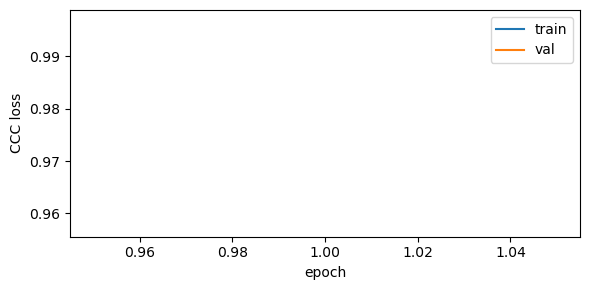

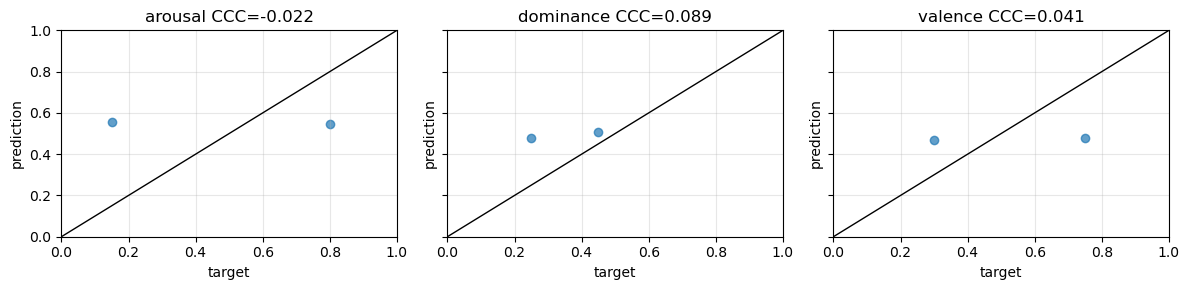

In [14]:
# このセルでは、学習履歴や予測値を可視化し、損失推移とVAD推定の傾向を確認する。

if fold_results:
    result = fold_results[-1]
    history = result['history']
    plt.figure(figsize=(6, 3))
    plt.plot([item['epoch'] for item in history], [item['train_loss'] for item in history], label='train')
    plt.plot([item['epoch'] for item in history], [item['val_loss'] for item in history], label='val')
    plt.xlabel('epoch')
    plt.ylabel('CCC loss')
    plt.legend()
    plt.tight_layout()

    pred = result['test']['pred']
    target = result['test']['target']
    mask = result['test']['mask']
    if pred is not None and len(pred) > 0:
        fig, axes = plt.subplots(1, 3, figsize=(12, 3), sharex=True, sharey=True)
        for i, name in enumerate(VAD_OUTPUT_NAMES):
            valid = mask[:, i].astype(bool)
            axes[i].scatter(target[valid, i], pred[valid, i], alpha=0.7)
            axes[i].plot([0, 1], [0, 1], color='black', linewidth=1)
            axes[i].set_title(f'{name} CCC={result["test"]["ccc"].get(name, np.nan):.3f}')
            axes[i].set_xlabel('target')
            axes[i].set_ylabel('prediction')
            axes[i].set_xlim(0, 1)
            axes[i].set_ylim(0, 1)
            axes[i].grid(True, alpha=0.3)
        plt.tight_layout()


In [15]:
# このセルでは、任意の単一wavに対して学習済みVADモデルで推論する。

INFER_WAV = ''  # example: r'C:/path/to/audio.wav'

if INFER_WAV and last_model is not None:
    feats = extract_emotion2vec_features(INFER_WAV)
    feats = torch.from_numpy(feats).float().unsqueeze(0).to(DEVICE)
    padding_mask = torch.zeros(feats.shape[:2], dtype=torch.bool, device=DEVICE)
    last_model.eval()
    with torch.no_grad():
        pred = last_model(feats, padding_mask)
    print(vad_tensor_to_dict(pred))
else:
    print('Set INFER_WAV after training to run a single-file VAD prediction.')


Set INFER_WAV after training to run a single-file VAD prediction.
